# ML & Anomaly Detection

In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn import datasets
from sklearn.datasets import make_blobs, make_moons
from sklearn import preprocessing
import matplotlib.pyplot as plt
from numpy import quantile, where, random
import statistics as stat
import random as rd

### The data

In [6]:
def add_uniform_noise(X, noise_ratio=0.1, low=-3, high=3, random_state=0):
    rng = np.random.RandomState(random_state)
    n_noise = int(noise_ratio * len(X))
    X_noise = rng.uniform(low=low, high=high, size=(n_noise, X.shape[1]))
    return np.vstack([X, X_noise])

def plot_data(X, title="", anomalies_mask=None):
    plt.figure(figsize=(4,4))
    if anomalies_mask is None:
        plt.scatter(X[:, 0], X[:, 1], s=10)
    else:
        normal = ~anomalies_mask
        plt.scatter(X[normal, 0], X[normal, 1], s=10, label="normal")
        plt.scatter(X[anomalies_mask, 0], X[anomalies_mask, 1],
                    s=40, marker='x', label="anomaly")
        plt.legend()
    plt.title(title)
    plt.axis('equal')
    plt.show()

Taille dataset 1 : (440, 2)


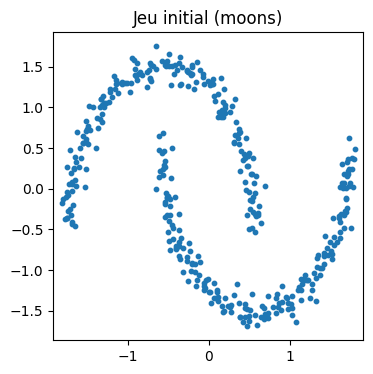

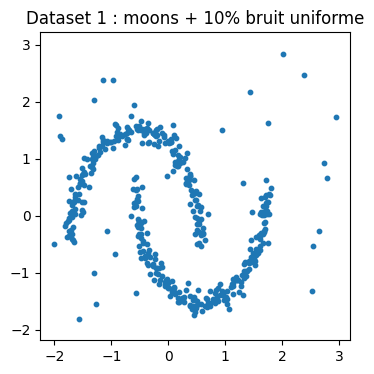

In [7]:
# Data set 1
n = 400
X0, y0 = datasets.make_moons(n_samples=n, noise=0.05, random_state=0)
X0 = preprocessing.scale(X0)

X1 = add_uniform_noise(X0, noise_ratio=0.1, low=-2, high=3, random_state=1)

print("Taille dataset 1 :", X1.shape)

plot_data(X0, "Jeu initial (moons)")
plot_data(X1, "Dataset 1 : moons + 10% bruit uniforme")


Taille dataset 2 : (220, 2)


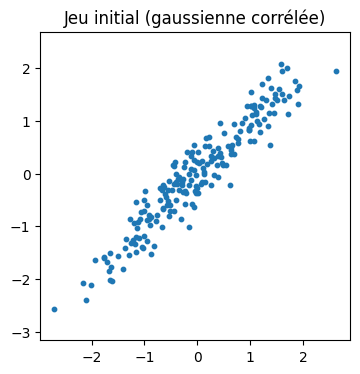

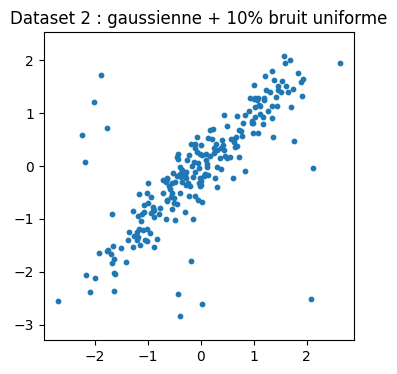

In [8]:
# Data set 2
NG1 = 200
mx1G1 = 0; mx2G1 = 0
sx1G1 = 1; sx2G1 = 1
rhoxG1 = 0.95

mu1 = np.array([mx1G1, mx2G1])
covxG1 = np.array([[sx1G1**2, rhoxG1*sx1G1*sx2G1],
                   [rhoxG1*sx1G1*sx2G1, sx2G1**2]])

XG1 = np.random.multivariate_normal(mu1, covxG1, NG1)
X0_2 = preprocessing.scale(XG1)

X2 = add_uniform_noise(X0_2, noise_ratio=0.1, low=-3, high=3, random_state=2)

print("Taille dataset 2 :", X2.shape)

plot_data(X0_2, "Jeu initial (gaussienne corrélée)")
plot_data(X2, "Dataset 2 : gaussienne + 10% bruit uniforme")


# Isolation Forest

Isolation Forest construit une forêt d’arbres qui isolent les points par des coupures aléatoires :

In [ ]:
def iso_forest_anomaly_detection(X, alpha=0.05, n_estimators=100, random_state=0):
    iforest = IsolationForest(n_estimators=n_estimators, contamination='auto', random_state=random_state)
    iforest.fit(X)
    
    # score_samples : plus le score est BAS, plus le point est suspect
    scores = iforest.score_samples(X)
    threshold = np.quantile(scores, alpha)  # quantile d'ordre 5% par défaut
    anomalies_mask = scores < threshold
    return anomalies_mask, scores, threshold


Nb d'anomalies (IF, data1) : 22


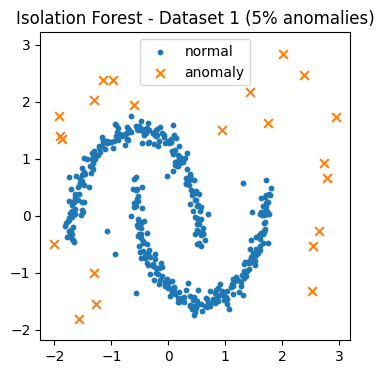

In [10]:
anomalies_1_if, scores_1, thr_1 = iso_forest_anomaly_detection(X1, alpha=0.05, random_state=0)
print("Nb d'anomalies (IF, data1) :", anomalies_1_if.sum())

plot_data(X1, f"Isolation Forest - Dataset 1 (5% anomalies)", anomalies_1_if)


Nb d'anomalies (IF, data2) : 11


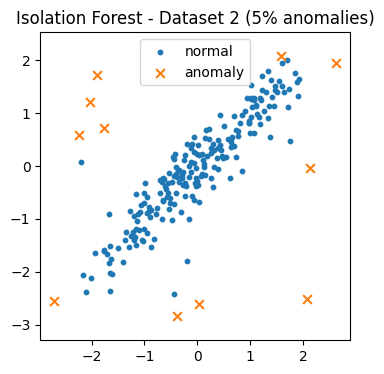

In [13]:
anomalies_2_if, scores_2, thr_2 = iso_forest_anomaly_detection(X2, alpha=0.05, random_state=0)
print("Nb d'anomalies (IF, data2) :", anomalies_2_if.sum())

plot_data(X2, f"Isolation Forest - Dataset 2 (5% anomalies)", anomalies_2_if)


## Local Outlier Factor

In [15]:
from sklearn.neighbors import LocalOutlierFactor
def lof_anomaly_detection(X, n_neighbors=20, contamination=0.01):
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    
    # fit_predict renvoie 1 pour normal, -1 pour outlier
    y_pred = lof.fit_predict(X)
    anomalies_mask = (y_pred == -1)
    scores = lof.negative_outlier_factor_  # plus c'est petit, plus c'est anormal
    return anomalies_mask, scores


Nb d'anomalies (LOF 1%, data1) : 5


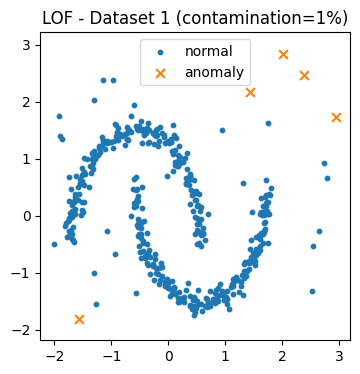

Nb d'anomalies (LOF 5%, data1) : 22


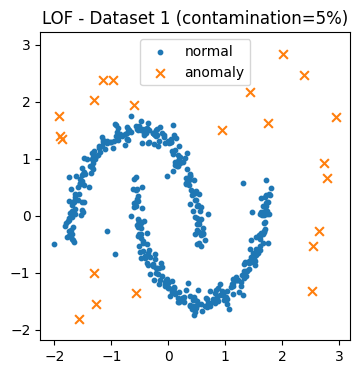

In [ ]:
anomalies_1_lof_1, scores_1_lof_1 = lof_anomaly_detection(X1, n_neighbors=20, contamination=0.01)
print("Nb d'anomalies (LOF 1%, data1) :", anomalies_1_lof_1.sum())
plot_data(X1, "LOF - Dataset 1 (contamination=1%)", anomalies_1_lof_1)

anomalies_1_lof_5, scores_1_lof_5 = lof_anomaly_detection(X1, n_neighbors=20, contamination=0.05)
print("Nb d'anomalies (LOF 5%, data1) :", anomalies_1_lof_5.sum())
plot_data(X1, "LOF - Dataset 1 (contamination=5%)", anomalies_1_lof_5)

Nb d'anomalies (LOF 5%, data2) : 11


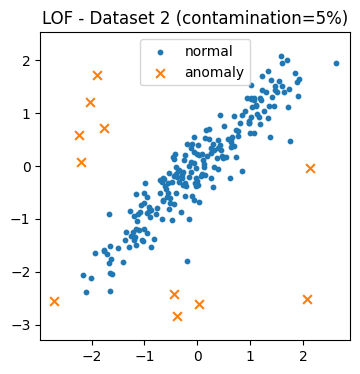

In [ ]:
anomalies_2_lof_5, scores_2_lof_5 = lof_anomaly_detection(X2, n_neighbors=20, contamination=0.05)
print("Nb d'anomalies (LOF 5%, data2) :", anomalies_2_lof_5.sum())
plot_data(X2, "LOF - Dataset 2 (contamination=5%)", anomalies_2_lof_5)

## Density Based Anomaly Detection (DBAD)
### Elliptical Envelope (Gaussian-based)

In [19]:
from sklearn.covariance import EllipticEnvelope
def elliptic_anomaly_detection(X, contamination=0.05, random_state=0):
    mod = EllipticEnvelope(
        contamination=contamination,
        random_state=random_state
    )
    y_pred = mod.fit_predict(X)   # 1 = inlier, -1 = outlier
    anomalies_mask = (y_pred == -1)
    scores = mod.decision_function(X)  # plus petit => plus anormal
    return anomalies_mask, scores, mod


Nb d'anomalies (EllipticEnvelope 1%, data1) : 5


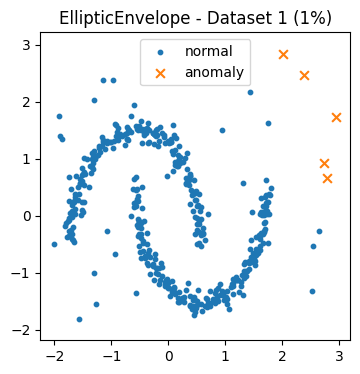

Nb d'anomalies (EllipticEnvelope 5%, data1) : 22


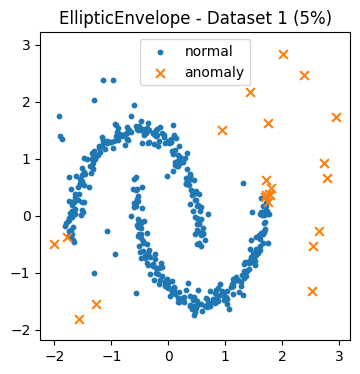

In [21]:
anomalies_1_db_1, scores_1_db_1, mod1 = elliptic_anomaly_detection(X1, contamination=0.01, random_state=0)
print("Nb d'anomalies (EllipticEnvelope 1%, data1) :", anomalies_1_db_1.sum())
plot_data(X1, "EllipticEnvelope - Dataset 1 (1%)", anomalies_1_db_1)

anomalies_1_db_5, scores_1_db_5, mod2 = elliptic_anomaly_detection(X1, contamination=0.05, random_state=0)
print("Nb d'anomalies (EllipticEnvelope 5%, data1) :", anomalies_1_db_5.sum())
plot_data(X1, "EllipticEnvelope - Dataset 1 (5%)", anomalies_1_db_5)

Nb d'anomalies (EllipticEnvelope 5%, data2) : 11


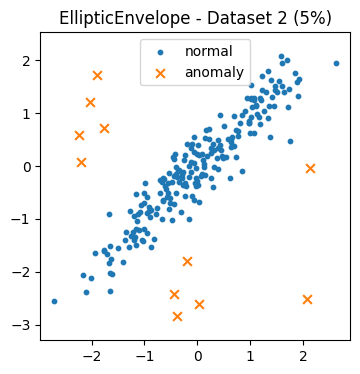

In [22]:
anomalies_2_db_5, scores_2_db_5, mod2 = elliptic_anomaly_detection(X2, contamination=0.05, random_state=0)
print("Nb d'anomalies (EllipticEnvelope 5%, data2) :", anomalies_2_db_5.sum())
plot_data(X2, "EllipticEnvelope - Dataset 2 (5%)", anomalies_2_db_5)

Dataset 1 (two moons + bruit)

Forme très non gaussienne.

- EllipticEnvelope ne fonctionne pas : il va essayer de mettre une grande ellipse sur tout le bazar.

- LOF est souvent très bon ici (local, suit les structures).

- Isolation Forest marche aussi pas mal, car il ne suppose pas de forme particulière.

Dataset 2 (gaussienne corrélée + bruit)

- C’est exactement ce qu’aime EllipticEnvelope (données elliptiques).

- Isolation Forest et LOF fonctionnent aussi, mais Elliptic est très adapté.